<a href="https://colab.research.google.com/github/avionerman/neural-networks-msc/blob/main/drl_pyflyt_ppo_sac_tqc_e2e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Βαθια Ενισχυτικη Μαθηση για Αυτονομη Πλοηγηση Fixed-Wing UAV

**Συγκριτικη μελετη PPO, SAC και TQC στο PyFlyt περιβαλλον**

---

## Σκοπος της εργασιας

Στοχος ειναι να εκπαιδευθουν και να αξιολογηθουν τρεις συγχρονοι αλγοριθμοι
βαθιας ενισχυτικης μαθησης (Deep Reinforcement Learning) ωστε ενα προσομοιωμενο
fixed-wing UAV (αεροπλανο σταθερων πτερυγιων) να μαθει αυτονομα να πετα απο
waypoint σε waypoint, χωρις χειροκινητα προγραμματισμενο controller.

## Αλγοριθμοι

| Αλγοριθμος | Ετος | Τυπος | Ρολος |
|---|---|---|---|
| **Random** | — | — | Lower-bound baseline |
| **PPO** (Schulman et al.) | 2017 | On-policy, policy gradient | Stable baseline |
| **SAC** (Haarnoja et al.) | 2018 | Off-policy, max-entropy | Modern continuous-control standard |
| **TQC** (Kuznetsov et al.) | 2020 | Off-policy, distributional critics | State-of-the-art |

## Περιβαλλον

`PyFlyt/Fixedwing-Waypoints-v3` — προσομοιωτης fixed-wing UAV βασισμενος σε
PyBullet physics, με Gymnasium API. Continuous action space (4 διαστασεις:
pitch, roll, yaw, throttle). Sparse rewards απο επιτυχημενο waypoint reaching.

## Σημειωση εκτελεσης

Λογω χρονικων περιορισμων (~24h Colab session), τα PPO και SAC models
εκπαιδευτηκαν σε προηγουμενο session και φορτωνονται μεσω της Section 6
(Migration). Τα TQC models εκπαιδευονται απο την αρχη σε αυτο το session
(Section 10). Αυτη η προσεγγιση ειναι ισοδυναμη με συνεχομενη εκπαιδευση —
ολα τα models εκπαιδευτηκαν με τα ιδια hyperparameters και ιδιο GPU type
(NVIDIA L4) στο Google Colab Pro.

## Metrics για το conclusion

- Mean episode return με 95% confidence interval (3 seeds)
- Success rate (% waypoints reached per episode)
- Sample efficiency curve (return vs env steps)
- Crash / out-of-bounds rate
- Action smoothness (L2 norm of consecutive action differences)
- Wall-clock training time
- GPU memory peak
- Episode length distribution


## 1. Εγκατασταση εξαρτησεων

**Σημαντικο για Colab:**

1. Τρεξε το επομενο cell **μια φορα μονο** στην αρχη του session
2. Θα κανει αυτοματο restart του kernel (θα δεις "Your session crashed" — ηθελημενο)
3. Μετα το restart **ΜΗΝ ξανατρεξεις το install cell**, προχωρα στο Section 2


In [ ]:
# Install dependencies (numpy pinned to 2.0.x for compat with pybullet/numba)
!pip install -q PyFlyt "stable-baselines3>=2.4" "sb3-contrib>=2.4" "gymnasium>=1.0"
!pip install -q --upgrade "numpy>=2.0,<2.1"
!pip install -q tensorboard pandas seaborn scipy

import os
print("Restarting kernel — this is intentional. Run the NEXT cell after restart.")
os.kill(os.getpid(), 9)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 32.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 51.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you hav

## 2. Imports και ρυθμισεις

Φορτωνουμε τις βιβλιοθηκες και θετουμε ολα τα hyperparameters σε ενα ενιαιο
`CONFIG` dict για ευκολη παραμετροποιηση.


In [1]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import gymnasium as gym
from scipy import stats

import PyFlyt.gym_envs  # noqa: F401  (registers PyFlyt envs in Gymnasium)
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from sb3_contrib import TQC

warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", context="talk")
torch.set_num_threads(4)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

ROOT = Path("./drl_pyflyt_runs")
ROOT.mkdir(exist_ok=True)
LOG_DIR = ROOT / "logs"
MODEL_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
for d in (LOG_DIR, MODEL_DIR, RESULTS_DIR):
    d.mkdir(exist_ok=True)


def _autodetect_env_id() -> str:
    """Pick the highest-version PyFlyt fixed-wing waypoint env available."""
    candidates = [
        "PyFlyt/Fixedwing-Waypoints-v3",
        "PyFlyt/Fixedwing-Waypoints-v2",
        "PyFlyt/Fixedwing-Waypoints-v1",
        "PyFlyt/Fixedwing-Waypoints-v0",
    ]
    registered = set(gym.envs.registry.keys())
    for env_id in candidates:
        if env_id in registered:
            return env_id
    raise RuntimeError("No PyFlyt Fixedwing-Waypoints env found.")


ENV_ID = _autodetect_env_id()
print(f"Using environment: {ENV_ID}")

CONFIG = {
    "env_id": ENV_ID,
    "total_timesteps": 500_000,
    "eval_freq": 25_000,
    "n_eval_episodes": 10,
    "n_seeds": 3,
    "seeds": [0, 1, 2],
    "final_eval_episodes": 30,
    "algorithms": ["PPO", "SAC", "TQC"],
}

print("\nConfiguration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


PyTorch device: cuda
GPU: NVIDIA L4
Using environment: PyFlyt/Fixedwing-Waypoints-v3

Configuration:
  env_id: PyFlyt/Fixedwing-Waypoints-v3
  total_timesteps: 500000
  eval_freq: 25000
  n_eval_episodes: 10
  n_seeds: 3
  seeds: [0, 1, 2]
  final_eval_episodes: 30
  algorithms: ['PPO', 'SAC', 'TQC']


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 3. Wrapper του observation και smoke test

Το PyFlyt Fixedwing env δινει Dict obs με Sequence component (μεταβλητο
πληθος waypoints). Το SB3 χρειαζεται flat Box. Ο `FixedwingObsWrapper` το
μετατρεπει.


In [2]:
class FixedwingObsWrapper(gym.ObservationWrapper):
    """Flatten PyFlyt Dict obs (attitude + Sequence of target_deltas) into a flat Box."""

    def __init__(self, env, num_future_waypoints: int = 3):
        super().__init__(env)
        self.num_future_waypoints = num_future_waypoints
        attitude_dim = env.observation_space["attitude"].shape[0]
        target_dim = 3 * num_future_waypoints
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(attitude_dim + target_dim,),
            dtype=np.float32,
        )

    def observation(self, obs):
        attitude = np.asarray(obs["attitude"], dtype=np.float32)
        targets = obs["target_deltas"]
        flat_targets = np.zeros((self.num_future_waypoints, 3), dtype=np.float32)
        if len(targets) > 0:
            arr = np.asarray(targets[:self.num_future_waypoints], dtype=np.float32)
            flat_targets[:len(arr)] = arr
        return np.concatenate([attitude, flat_targets.flatten()])


def make_base_env(monitor_path=None):
    env = gym.make(CONFIG["env_id"])
    env = FixedwingObsWrapper(env)
    env = Monitor(env, filename=monitor_path)
    return env


probe_env = make_base_env()
print(f"Observation space: {probe_env.observation_space}")
print(f"Action space:      {probe_env.action_space}")
obs, info = probe_env.reset(seed=42)
print(f"\nFirst observation shape: {np.asarray(obs).shape}")
print(f"First info keys: {list(info.keys())}")
probe_env.close()


Observation space: Box(-inf, inf, (32,), float32)
Action space:      Box(-1.0, 1.0, (4,), float64)
                             

First observation shape: (32,)
First info keys: ['out_of_bounds', 'collision', 'env_complete', 'num_targets_reached']


## 4. TrajectoryWrapper και metric utilities

Ενα wrapper που καταγραφει την τροχια (3D θεση), τις ενεργειες, και τα info
flags σε καθε episode. Χρησιμευει για τα plots τροχιας, τη μετρηση action
smoothness, και τον ελεγχο για crash/out-of-bounds.


In [3]:
class TrajectoryWrapper(gym.Wrapper):
    """Records 3D position, actions and termination causes per episode."""

    def __init__(self, env):
        super().__init__(env)
        self._reset_buffers()

    def _reset_buffers(self):
        self.positions = []
        self.actions = []
        self.last_info = {}

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._reset_buffers()
        self._capture_position()
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.actions.append(np.asarray(action, dtype=np.float32).copy())
        self._capture_position()
        self.last_info = info
        return obs, reward, terminated, truncated, info

    def _capture_position(self):
        """Best-effort extraction of UAV xyz position from PyFlyt internals."""
        try:
            state = self.env.unwrapped.aviary.state(0)
            pos = np.asarray(state[3], dtype=np.float32)
            self.positions.append(pos.copy())
        except Exception:
            pass


def compute_action_smoothness(actions: list) -> float:
    """Mean L2 norm of consecutive action differences (lower = smoother)."""
    if len(actions) < 2:
        return 0.0
    arr = np.stack(actions, axis=0)
    diffs = np.linalg.norm(arr[1:] - arr[:-1], axis=1)
    return float(diffs.mean())


def parse_episode_outcome(info: dict) -> dict:
    """Extract success / crash flags from PyFlyt info dict."""
    return {
        "env_complete": bool(info.get("env_complete", False)),
        "num_targets_reached": int(info.get("num_targets_reached", 0)),
        "collision": bool(info.get("collision", False)),
        "out_of_bounds": bool(info.get("out_of_bounds", False)),
    }


## 5. Random policy baseline

> ⚠️ **Skip σε αυτη την εκτελεση** — το `random_df` φορτωνεται απο το upload zip
> στη Section 6 (Migration). Το cell εκτελεστηκε σε προηγουμενο session και
> τα αποτελεσματα του διατηρουνται για συνεπεια.

Πριν εκπαιδευσουμε οτιδηποτε, μετραμε τη performance ενος policy που επιλεγει
ενεργειες τυχαια. Αυτο μας δινει ενα lower bound: αν ενας αλγοριθμος δεν το
ξεπερναει σαφως, δεν εχει μαθει τιποτα.


In [ ]:
def evaluate_random_policy(n_episodes: int = 30, seed: int = 0) -> pd.DataFrame:
    """Run a uniformly random policy for n_episodes and collect metrics."""
    raw = make_base_env()
    env = TrajectoryWrapper(raw)

    rows = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        steps = 0
        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            steps += 1
            done = terminated or truncated

        outcome = parse_episode_outcome(env.last_info)
        rows.append({
            "episode": ep,
            "return": total_reward,
            "length": steps,
            "smoothness": compute_action_smoothness(env.actions),
            **outcome,
        })
    env.close()
    return pd.DataFrame(rows)


# Skipped in this execution — random_df is loaded from upload in Section 6.
# To run a fresh baseline, uncomment the lines below:
# print("Running random baseline...")
# random_df = evaluate_random_policy(n_episodes=CONFIG["final_eval_episodes"])
# random_df.to_csv(RESULTS_DIR / "random_baseline.csv", index=False)
# print(random_df[["return", "length", "num_targets_reached"]].describe().round(3))


## 6. Migration — upload τοπικων αποτελεσματων PPO + SAC

Στο τοπικο σου μηχανημα εχεις το αρχειο `upload_to_colab.zip` που περιεχει:

- Τα 3 PPO models (`logs-ppo/PPO_seed{0,1,2}.zip`)
- Τα 3 SAC models (`logs-sac/SAC_seed{0,1,2}.zip`)
- Τα `evaluations.npz` και `monitor.csv` αρχεια για learning curves
- Το `random_baseline.csv`

Οταν τρεξει το επομενο cell, θα εμφανιστει κουμπι "Choose Files" — ανεβασε το
zip. Το cell θα τα οργανωσει αυτοματα στον φακελο `drl_pyflyt_runs/`.


In [4]:
import shutil
import zipfile
from google.colab import files

# === Step 1: Upload your local "upload_to_colab.zip" ===
print("Click 'Choose Files' below and upload upload_to_colab.zip from your local machine...")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
print(f"Uploaded: {zip_filename}")

# === Step 2: Extract ===
extract_dir = Path("uploaded_local_results")
shutil.rmtree(extract_dir, ignore_errors=True)
extract_dir.mkdir()
with zipfile.ZipFile(zip_filename, "r") as zf:
    zf.extractall(extract_dir)

candidates = list(extract_dir.rglob("logs-ppo"))
if not candidates:
    raise RuntimeError("Could not find 'logs-ppo' inside the uploaded zip")
local_root = candidates[0].parent
print(f"Local results root: {local_root}\n")


# === Step 3: Migrate PPO and SAC into expected structure ===
def migrate_algo(algo_name: str, src_subfolder: str):
    src_dir = local_root / src_subfolder
    if not src_dir.exists():
        print(f"  Skip {algo_name}: missing {src_dir}")
        return

    # Final model checkpoints: PPO_seedX.zip -> models/
    for zip_path in sorted(src_dir.glob(f"{algo_name}_seed*.zip")):
        shutil.copy(zip_path, MODEL_DIR / zip_path.name)
        print(f"  models/{zip_path.name}")

    # Per-seed log folders: seedX/ -> logs/{algo}_seedX/
    for seed_folder in sorted(src_dir.glob("seed*")):
        if seed_folder.is_dir():
            seed_num = seed_folder.name.replace("seed", "")
            target = LOG_DIR / f"{algo_name}_seed{seed_num}"
            target.mkdir(parents=True, exist_ok=True)
            for f in seed_folder.iterdir():
                if f.is_file():
                    shutil.copy(f, target / f.name)
            print(f"  logs/{algo_name}_seed{seed_num}/")


migrate_algo("PPO", "logs-ppo")
migrate_algo("SAC", "logs-sac")


# === Step 4: Load random_baseline as random_df ===
rb_src = local_root / "random_baseline.csv"
if rb_src.exists():
    shutil.copy(rb_src, RESULTS_DIR / "random_baseline.csv")
    random_df = pd.read_csv(RESULTS_DIR / "random_baseline.csv")
    print(f"\n  random_df loaded: {len(random_df)} episodes")
else:
    print("\n  WARNING: random_baseline.csv not found in zip!")
    random_df = pd.DataFrame()

print("\n  Migration complete. Continue to Section 7.")


Click 'Choose Files' below and upload upload_to_colab.zip from your local machine...


Saving upload_to_colab.zip to upload_to_colab (1).zip
Uploaded: upload_to_colab (1).zip
Local results root: uploaded_local_results

  models/PPO_seed0.zip
  models/PPO_seed1.zip
  models/PPO_seed2.zip
  logs/PPO_seed0/
  logs/PPO_seed1/
  logs/PPO_seed2/
  models/SAC_seed0.zip
  models/SAC_seed1.zip
  models/SAC_seed2.zip
  logs/SAC_seed0/
  logs/SAC_seed1/
  logs/SAC_seed2/

  random_df loaded: 30 episodes

  Migration complete. Continue to Section 7.


In [5]:
from google.colab import drive
import shutil

# Mount Google Drive — popup θα ζητησει Google login την πρωτη φορα
drive.mount('/content/drive')

# Override output paths to live on Drive
DRIVE_ROOT = Path("/content/drive/MyDrive/drl_pyflyt_runs")
LOG_DIR = DRIVE_ROOT / "logs"
MODEL_DIR = DRIVE_ROOT / "models"
RESULTS_DIR = DRIVE_ROOT / "results"
for d in (LOG_DIR, MODEL_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Copy whatever we already have locally (PPO+SAC from Section 6) over to Drive
local_root = Path("./drl_pyflyt_runs")
if local_root.exists():
    # Models (PPO_seedX.zip, SAC_seedX.zip)
    for src_zip in (local_root / "models").glob("*.zip"):
        dst = MODEL_DIR / src_zip.name
        if not dst.exists():
            shutil.copy(src_zip, dst)
            print(f"  models/ <- {src_zip.name}")
    # Log folders (PPO_seed0/, SAC_seed1/, ...)
    for src_dir in (local_root / "logs").glob("*_seed*"):
        if src_dir.is_dir():
            target = LOG_DIR / src_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for f in src_dir.iterdir():
                if f.is_file() and not (target / f.name).exists():
                    shutil.copy(f, target / f.name)
            print(f"  logs/ <- {src_dir.name}/")
    # Random baseline CSV
    rb = local_root / "results" / "random_baseline.csv"
    if rb.exists():
        dst = RESULTS_DIR / "random_baseline.csv"
        if not dst.exists():
            shutil.copy(rb, dst)
            print(f"  results/ <- random_baseline.csv")

print(f"\nMount complete. TQC training will save to: {MODEL_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  logs/ <- SAC_seed1/
  logs/ <- PPO_seed1/
  logs/ <- PPO_seed2/
  logs/ <- SAC_seed2/
  logs/ <- SAC_seed0/
  logs/ <- PPO_seed0/

Mount complete. TQC training will save to: /content/drive/MyDrive/drl_pyflyt_runs/models


## 7. Helper για εκπαιδευση + logging

Καθε αλγοριθμος εκπαιδευεται με την ιδια ρουτινα ωστε η συγκριση να ειναι
fair. Καταγραφουμε:

- Καμπυλη μαθησης μεσω `EvalCallback`
- Wall-clock χρονο εκπαιδευσης
- GPU memory peak
- Final policy weights αποθηκευμενα στο δισκο


In [6]:
ALGO_REGISTRY = {
    "PPO": {
        "cls": PPO,
        "kwargs": {
            "policy": "MlpPolicy",
            "n_steps": 2048,
            "batch_size": 64,
            "n_epochs": 10,
            "gamma": 0.99,
            "gae_lambda": 0.95,
            "clip_range": 0.2,
            "learning_rate": 3e-4,
            "verbose": 0,
        },
    },
    "SAC": {
        "cls": SAC,
        "kwargs": {
            "policy": "MlpPolicy",
            "buffer_size": 200_000,
            "learning_starts": 5_000,
            "batch_size": 256,
            "tau": 0.005,
            "gamma": 0.99,
            "train_freq": 1,
            "gradient_steps": 1,
            "learning_rate": 3e-4,
            "verbose": 0,
        },
    },
    "TQC": {
        "cls": TQC,
        "kwargs": {
            "policy": "MlpPolicy",
            "buffer_size": 200_000,
            "learning_starts": 5_000,
            "batch_size": 256,
            "tau": 0.005,
            "gamma": 0.99,
            "train_freq": 1,
            "gradient_steps": 1,
            "learning_rate": 3e-4,
            "top_quantiles_to_drop_per_net": 2,
            "verbose": 0,
        },
    },
}


def train_one_run(algo_name: str, seed: int) -> dict:
    """Train a single (algorithm, seed) combination and return run metadata."""
    run_id = f"{algo_name}_seed{seed}"
    run_log_dir = LOG_DIR / run_id
    run_model_path = MODEL_DIR / f"{run_id}.zip"
    run_log_dir.mkdir(parents=True, exist_ok=True)

    train_env = make_base_env(monitor_path=str(run_log_dir / "train"))
    eval_env = make_base_env(monitor_path=str(run_log_dir / "eval"))

    spec = ALGO_REGISTRY[algo_name]
    model = spec["cls"](
        env=train_env, seed=seed, device=DEVICE,
        tensorboard_log=str(LOG_DIR / "tb"), **spec["kwargs"],
    )

    eval_callback = EvalCallback(
        eval_env, best_model_save_path=str(run_log_dir),
        log_path=str(run_log_dir),
        eval_freq=CONFIG["eval_freq"],
        n_eval_episodes=CONFIG["n_eval_episodes"],
        deterministic=True, render=False, verbose=0,
    )

    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()

    model.learn(
        total_timesteps=CONFIG["total_timesteps"],
        callback=eval_callback,
        tb_log_name=run_id,
        progress_bar=True,
    )

    wall = time.perf_counter() - t0
    gpu_mem_mb = (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if DEVICE == "cuda" else 0.0
    )

    model.save(run_model_path)
    train_env.close()
    eval_env.close()

    return {
        "algo": algo_name, "seed": seed,
        "wall_clock_s": wall, "gpu_mem_mb": gpu_mem_mb,
        "model_path": str(run_model_path),
        "log_dir": str(run_log_dir),
    }


## 8. Εκπαιδευση PPO (3 seeds)

> ⚠️ **Skip σε αυτη την εκτελεση** — τα PPO models εκπαιδευτηκαν σε προηγουμενο
> Colab session και φορτωθηκαν μεσω Section 6 (Migration). Ο κωδικας παραμενει
> εδω για αναφορα και αναπαραγωγιμοτητα.

PPO ειναι on-policy: συλλεγει rollouts και κανει update. Σταθερο, εξυπνο
baseline. Αναμενουμε σχετικα αργη συγκλιση αλλα ομαλη καμπυλη.


In [ ]:
# Skipped — PPO models loaded from upload in Section 6.
# To re-train from scratch, uncomment the loop below:

ppo_runs = []
for seed in CONFIG["seeds"]:
    print(f"\n=== Training PPO seed={seed} ===")
    result = train_one_run("PPO", seed)
    ppo_runs.append(result)
    print(f"  wall_clock: {result['wall_clock_s']:.1f}s | gpu_peak: {result['gpu_mem_mb']:.1f} MB")
with open(RESULTS_DIR / "ppo_runs.json", "w") as f:
    json.dump(ppo_runs, f, indent=2)

print("PPO training skipped — models loaded from upload in Section 6.")


## 9. Εκπαιδευση SAC (3 seeds)

> ⚠️ **Skip σε αυτη την εκτελεση** — τα SAC models εκπαιδευτηκαν σε προηγουμενο
> Colab session και φορτωθηκαν μεσω Section 6 (Migration). Ο κωδικας παραμενει
> εδω για αναφορα και αναπαραγωγιμοτητα.

SAC ειναι off-policy με maximum entropy objective. Συνηθως ο default winner
σε continuous control. Αναμενουμε ταχυτερη συγκλιση απο PPO.


In [ ]:
# Skipped — SAC models loaded from upload in Section 6.
# To re-train from scratch, uncomment the loop below:

sac_runs = []
for seed in CONFIG["seeds"]:
    print(f"\n=== Training SAC seed={seed} ===")
    result = train_one_run("SAC", seed)
    sac_runs.append(result)
    print(f"  wall_clock: {result['wall_clock_s']:.1f}s | gpu_peak: {result['gpu_mem_mb']:.1f} MB")
with open(RESULTS_DIR / "sac_runs.json", "w") as f:
   json.dump(sac_runs, f, indent=2)

print("SAC training skipped — models loaded from upload in Section 6.")


In [7]:
# Switch training output back to LOCAL disk (Drive has sync issues with frequent writes)
import shutil

DRIVE_BACKUP = Path("/content/drive/MyDrive/drl_pyflyt_runs")

LOCAL_ROOT = Path("./drl_pyflyt_runs")
LOG_DIR = LOCAL_ROOT / "logs"
MODEL_DIR = LOCAL_ROOT / "models"
RESULTS_DIR = LOCAL_ROOT / "results"
for d in (LOG_DIR, MODEL_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Re-import PPO+SAC from Drive backup to local (so smart resume works)
for src in (DRIVE_BACKUP / "models").glob("*.zip"):
    dst = MODEL_DIR / src.name
    if not dst.exists():
        shutil.copy(src, dst)
        print(f"  models/ <- {src.name}")

for src_dir in (DRIVE_BACKUP / "logs").glob("*_seed*"):
    if src_dir.is_dir():
        target = LOG_DIR / src_dir.name
        target.mkdir(parents=True, exist_ok=True)
        for f in src_dir.iterdir():
            if f.is_file():
                dst = target / f.name
                if not dst.exists():
                    shutil.copy(f, dst)
        print(f"  logs/ <- {src_dir.name}/")

rb = DRIVE_BACKUP / "results" / "random_baseline.csv"
if rb.exists():
    shutil.copy(rb, RESULTS_DIR / "random_baseline.csv")

def backup_to_drive():
    """Mirror current local training output to the Drive backup folder."""
    (DRIVE_BACKUP / "models").mkdir(parents=True, exist_ok=True)
    (DRIVE_BACKUP / "logs").mkdir(parents=True, exist_ok=True)
    for src in MODEL_DIR.glob("*.zip"):
        shutil.copy(src, DRIVE_BACKUP / "models" / src.name)
    for src_dir in LOG_DIR.glob("*_seed*"):
        if src_dir.is_dir():
            target = DRIVE_BACKUP / "logs" / src_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for f in src_dir.iterdir():
                if f.is_file():
                    shutil.copy(f, target / f.name)
    print(f"  -> backed up to {DRIVE_BACKUP}")

print(f"\nLOG_DIR    = {LOG_DIR}  (local, fast)")
print(f"MODEL_DIR  = {MODEL_DIR}  (local, fast)")
print(f"DRIVE backup = {DRIVE_BACKUP}  (after each seed)")


  logs/ <- SAC_seed1/
  logs/ <- PPO_seed1/
  logs/ <- PPO_seed2/
  logs/ <- SAC_seed2/
  logs/ <- SAC_seed0/
  logs/ <- PPO_seed0/

LOG_DIR    = drl_pyflyt_runs/logs  (local, fast)
MODEL_DIR  = drl_pyflyt_runs/models  (local, fast)
DRIVE backup = /content/drive/MyDrive/drl_pyflyt_runs  (after each seed)


## 10. Εκπαιδευση TQC (3 seeds)

TQC = Truncated Quantile Critics (Kuznetsov et al., 2020). Distributional
critic με truncation των πιο αισιοδοξων quantiles → μειωμενο overestimation
bias σε σχεση με SAC.

**Χρονος: ~2 ωρες ανα seed σε L4 GPU. Συνολικα ~6 ωρες.**

**Smart resume:** Αν το cell διακοπει στη μεση και ξανατρεξει, θα παραλειψει
seeds που εχουν ηδη model file στο δισκο.


In [8]:
tqc_runs = []
for seed in CONFIG["seeds"]:
    model_path = MODEL_DIR / f"TQC_seed{seed}.zip"
    if model_path.exists():
        print(f"\n=== TQC seed={seed} already trained — skipping ===")
        tqc_runs.append({
            "algo": "TQC", "seed": seed,
            "wall_clock_s": 0.0, "gpu_mem_mb": 0.0,
            "model_path": str(model_path),
            "log_dir": str(LOG_DIR / f"TQC_seed{seed}"),
        })
        continue

    print(f"\n=== Training TQC seed={seed} ===")
    result = train_one_run("TQC", seed)
    tqc_runs.append(result)
    print(f"  wall_clock: {result['wall_clock_s']:.1f}s | gpu_peak: {result['gpu_mem_mb']:.1f} MB")

    # Backup local outputs to Drive after every completed seed
    backup_to_drive()

with open(RESULTS_DIR / "tqc_runs.json", "w") as f:
    json.dump(tqc_runs, f, indent=2)
backup_to_drive()  # one final sync
print(f"\nDone. {len(tqc_runs)} TQC seeds available.")



=== Training TQC seed=0 ===


Output()

  wall_clock: 8620.6s | gpu_peak: 36.3 MB


Output()

  -> backed up to /content/drive/MyDrive/drl_pyflyt_runs

=== Training TQC seed=1 ===
                             


  wall_clock: 8831.7s | gpu_peak: 40.6 MB


Output()

  -> backed up to /content/drive/MyDrive/drl_pyflyt_runs

=== Training TQC seed=2 ===
                             


  wall_clock: 8765.5s | gpu_peak: 40.6 MB
  -> backed up to /content/drive/MyDrive/drl_pyflyt_runs
  -> backed up to /content/drive/MyDrive/drl_pyflyt_runs

Done. 3 TQC seeds available.


## 11. Τελικη αξιολογηση ολων των 9 models

Σκαναρει το `MODEL_DIR/` για ολα τα `.zip` αρχεια (PPO_seed*, SAC_seed*,
TQC_seed*), τα φορτωνει και τρεχει `final_eval_episodes` deterministic
episodes ανα model. Καταγραφει ολες τις μετρικες της εργασιας.


In [9]:
import re

# Discover all available trained models on disk
existing_models = []
for model_zip in sorted(MODEL_DIR.glob("*.zip")):
    match = re.match(r"(\w+)_seed(\d+)\.zip", model_zip.name)
    if match:
        algo, seed = match.group(1), int(match.group(2))
        if algo in ALGO_REGISTRY:
            existing_models.append({
                "algo": algo,
                "seed": seed,
                "model_path": str(model_zip),
                "log_dir": str(LOG_DIR / f"{algo}_seed{seed}"),
                "wall_clock_s": 0.0,
                "gpu_mem_mb": 0.0,
            })

print(f"Found {len(existing_models)} trained models:")
for m in existing_models:
    print(f"  {m['algo']} seed={m['seed']}")

all_runs = existing_models


def evaluate_trained_model(model_path, algo_name, n_episodes, seed_offset):
    """Run trained policy deterministically and collect per-episode metrics."""
    cls = ALGO_REGISTRY[algo_name]["cls"]
    raw = make_base_env()
    env = TrajectoryWrapper(raw)
    model = cls.load(model_path, device=DEVICE)

    rows = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=10_000 + seed_offset * 100 + ep)
        done = False
        total_reward = 0.0
        steps = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            steps += 1
            done = terminated or truncated
        outcome = parse_episode_outcome(env.last_info)
        rows.append({
            "episode": ep,
            "return": total_reward,
            "length": steps,
            "smoothness": compute_action_smoothness(env.actions),
            **outcome,
        })
    env.close()
    return pd.DataFrame(rows)


eval_records = []
for run in all_runs:
    print(f"Evaluating {run['algo']} seed={run['seed']}...")
    df = evaluate_trained_model(
        run["model_path"], run["algo"],
        n_episodes=CONFIG["final_eval_episodes"],
        seed_offset=run["seed"],
    )
    df["algo"] = run["algo"]
    df["seed"] = run["seed"]
    df["wall_clock_s"] = run["wall_clock_s"]
    df["gpu_mem_mb"] = run["gpu_mem_mb"]
    eval_records.append(df)

# Random baseline as reference
if not random_df.empty:
    rdf = random_df.copy()
    rdf["algo"] = "Random"
    rdf["seed"] = 0
    rdf["wall_clock_s"] = 0.0
    rdf["gpu_mem_mb"] = 0.0
    eval_records.append(rdf)

eval_all = pd.concat(eval_records, ignore_index=True)
eval_all.to_csv(RESULTS_DIR / "final_evaluation.csv", index=False)
print(f"\nCollected {len(eval_all)} episodes across {eval_all['algo'].nunique()} algorithms.")


Found 9 trained models:
  PPO seed=0
  PPO seed=1
  PPO seed=2
  SAC seed=0
  SAC seed=1
  SAC seed=2
  TQC seed=0
  TQC seed=1
  TQC seed=2
Evaluating PPO seed=0...
                             


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
Evaluating PPO seed=1...
                             


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
Evaluating PPO seed=2...
                             


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
                             
Evaluating SAC seed=0...
                             
                             
                             
               

## 12. Καμπυλες μαθησης (sample efficiency)

Φορτωνουμε τα `evaluations.npz` που εγραψε το `EvalCallback` σε καθε run και
σχεδιαζουμε mean reward vs env steps με 95% confidence interval bands απο τα
3 seeds. Δειχνει ποιος αλγοριθμος ειναι sample-efficient.


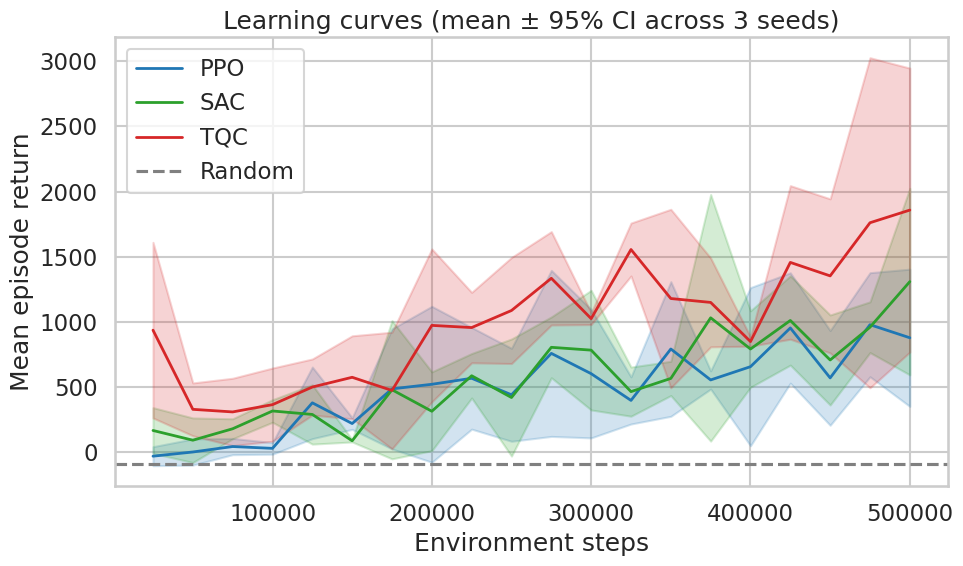

In [10]:
def load_eval_curve(log_dir: str) -> pd.DataFrame:
    npz_path = Path(log_dir) / "evaluations.npz"
    if not npz_path.exists():
        return pd.DataFrame(columns=["timesteps", "mean_reward", "std_reward"])
    data = np.load(npz_path)
    return pd.DataFrame({
        "timesteps": data["timesteps"],
        "mean_reward": data["results"].mean(axis=1),
        "std_reward": data["results"].std(axis=1),
    })


curves = []
for run in all_runs:
    df = load_eval_curve(run["log_dir"])
    df["algo"] = run["algo"]
    df["seed"] = run["seed"]
    curves.append(df)
curves_df = pd.concat(curves, ignore_index=True)
curves_df.to_csv(RESULTS_DIR / "learning_curves.csv", index=False)

palette = {"PPO": "#1f77b4", "SAC": "#2ca02c", "TQC": "#d62728"}

fig, ax = plt.subplots(figsize=(10, 6))
for algo, sub in curves_df.groupby("algo"):
    pivot = sub.pivot_table(index="timesteps", columns="seed", values="mean_reward")
    mean = pivot.mean(axis=1)
    sem = pivot.sem(axis=1)
    ci95 = 1.96 * sem
    ax.plot(pivot.index, mean, label=algo, color=palette.get(algo), linewidth=2)
    ax.fill_between(pivot.index, mean - ci95, mean + ci95,
                    color=palette.get(algo), alpha=0.2)

if not random_df.empty:
    ax.axhline(random_df["return"].mean(), linestyle="--",
               color="gray", label="Random")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Mean episode return")
ax.set_title("Learning curves (mean ± 95% CI across 3 seeds)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=150)
plt.show()


## 13. Συγκριση metrics μεταξυ αλγοριθμων

Bar charts με 95% CI για ολες τις βασικες μετρικες της εργασιας.


Per-algorithm metrics (mean across seeds):
     algo  seed_mean  seed_ci95  return_mean_mean  return_mean_ci95  \
0     PPO        1.0      1.132           637.626           160.114   
1  Random        0.0      0.000           -92.581             0.000   
2     SAC        1.0      1.132           832.272           249.911   
3     TQC        1.0      1.132          1266.943           287.043   

   success_rate_mean  success_rate_ci95  waypoint_count_mean  \
0              0.000              0.000                0.056   
1              0.000              0.000                0.000   
2              0.000              0.000                0.167   
3              0.011              0.022                0.467   

   waypoint_count_ci95  crash_rate_mean  crash_rate_ci95  oob_rate_mean  \
0                0.079            0.767            0.038          0.044   
1                0.000            0.900            0.000          0.100   
2                0.151            0.656            0.11

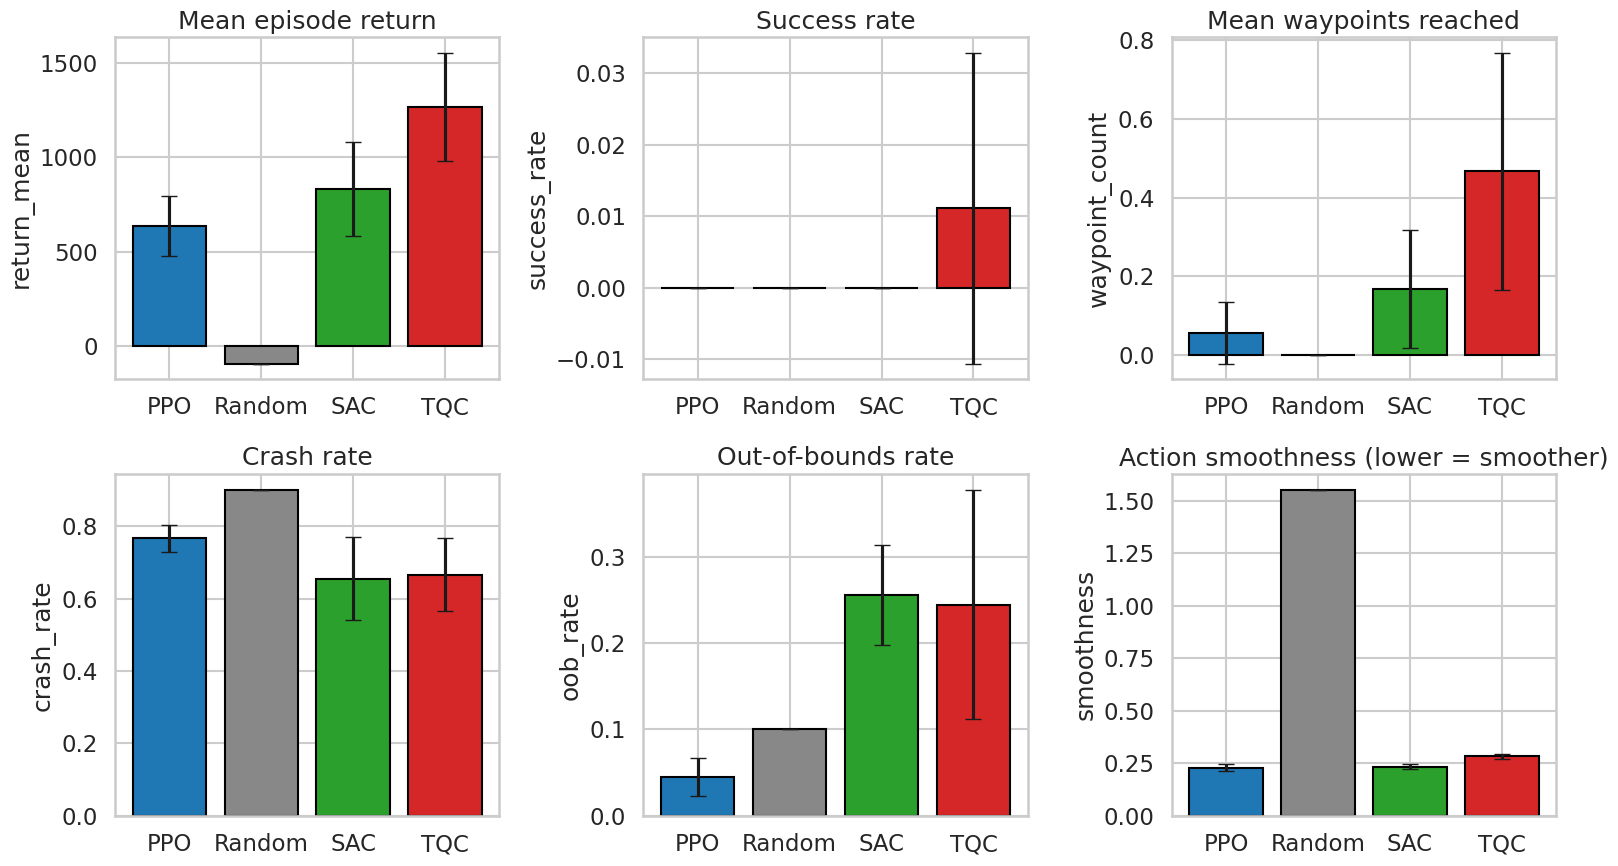

In [11]:
def ci95(series: pd.Series) -> float:
    return 1.96 * series.sem() if len(series) > 1 else 0.0


per_seed = eval_all.groupby(["algo", "seed"]).agg(
    return_mean=("return", "mean"),
    success_rate=("env_complete", "mean"),
    waypoint_count=("num_targets_reached", "mean"),
    crash_rate=("collision", "mean"),
    oob_rate=("out_of_bounds", "mean"),
    smoothness=("smoothness", "mean"),
    ep_length=("length", "mean"),
).reset_index()

agg = per_seed.groupby("algo").agg(["mean", ci95])
agg.columns = [f"{c[0]}_{c[1]}" for c in agg.columns]
agg = agg.reset_index()
agg.to_csv(RESULTS_DIR / "metrics_summary.csv", index=False)

print("Per-algorithm metrics (mean across seeds):")
print(agg.round(3))

metric_panels = [
    ("return_mean", "Mean episode return"),
    ("success_rate", "Success rate"),
    ("waypoint_count", "Mean waypoints reached"),
    ("crash_rate", "Crash rate"),
    ("oob_rate", "Out-of-bounds rate"),
    ("smoothness", "Action smoothness (lower = smoother)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (key, title) in zip(axes.flatten(), metric_panels):
    means = agg[f"{key}_mean"]
    cis = agg[f"{key}_ci95"]
    colors = [palette.get(a, "#888") for a in agg["algo"]]
    ax.bar(agg["algo"], means, yerr=cis, capsize=6,
           color=colors, edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel(key)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_bar_charts.png", dpi=150)
plt.show()


## 14. 3D τροχιες πτησης

Για καθε αλγοριθμο τραβαμε ενα episode και σχεδιαζουμε την 3D τροχια του
αεροπλανου. Δινει visual διαισθηση για το πως πετα ο agent.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


/tmp/ipykernel_15211/962749802.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


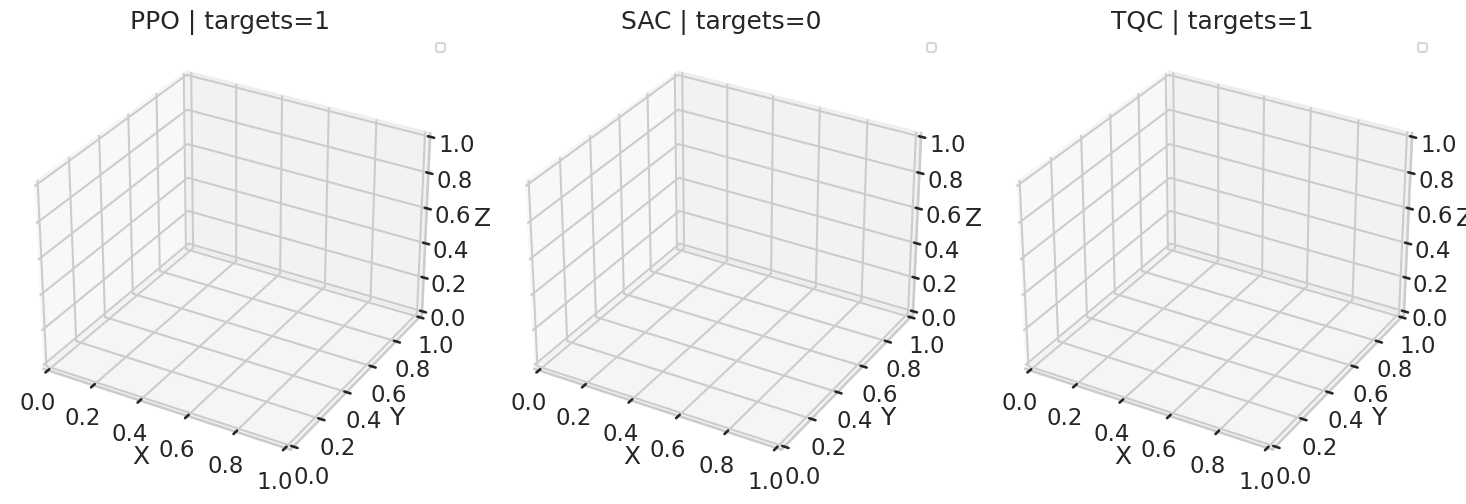

In [12]:
def collect_one_trajectory(model_path, algo_name, seed):
    cls = ALGO_REGISTRY[algo_name]["cls"]
    raw = make_base_env()
    env = TrajectoryWrapper(raw)
    model = cls.load(model_path, device=DEVICE)

    obs, _ = env.reset(seed=seed)
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    traj = np.asarray(env.positions) if env.positions else np.empty((0, 3))
    info = parse_episode_outcome(env.last_info)
    env.close()
    return traj, info


fig = plt.figure(figsize=(15, 5))
for idx, algo in enumerate(["PPO", "SAC", "TQC"]):
    runs_for_algo = [r for r in all_runs if r["algo"] == algo]
    if not runs_for_algo:
        continue
    best_run = runs_for_algo[0]
    traj, info = collect_one_trajectory(best_run["model_path"], algo, seed=99)

    ax = fig.add_subplot(1, 3, idx + 1, projection="3d")
    if traj.size:
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
                color=palette[algo], linewidth=1.5)
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2],
                   color="green", s=60, label="start")
        ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2],
                   color="red", s=60, label="end")
    ax.set_title(f"{algo} | targets={info['num_targets_reached']}")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "trajectories_3d.png", dpi=150)
plt.show()


## 15. Στατιστικοι ελεγχοι

Pairwise comparisons μεταξυ των αλγοριθμων στο final episode return:

- **Welch's t-test** (παραμετρικο, υποθετει approx. normal sample mean)
- **Mann-Whitney U** (non-parametric, robust)

Αν p < 0.05 για καποιο pair, η διαφορα ειναι στατιστικα σημαντικη.


In [13]:
def pairwise_tests(df: pd.DataFrame, metric: str = "return") -> pd.DataFrame:
    algos = sorted(df["algo"].unique().tolist())
    rows = []
    for i, a in enumerate(algos):
        for b in algos[i + 1:]:
            x = df[df["algo"] == a][metric].values
            y = df[df["algo"] == b][metric].values
            t_stat, t_p = stats.ttest_ind(x, y, equal_var=False)
            u_stat, u_p = stats.mannwhitneyu(x, y, alternative="two-sided")
            rows.append({
                "comparison": f"{a} vs {b}",
                "mean_diff": float(np.mean(x) - np.mean(y)),
                "welch_t": t_stat, "welch_p": t_p,
                "mannwhitney_U": u_stat, "mannwhitney_p": u_p,
                "significant_0.05": bool(min(t_p, u_p) < 0.05),
            })
    return pd.DataFrame(rows)


tests_df = pairwise_tests(eval_all[eval_all["algo"] != "Random"])
tests_df.to_csv(RESULTS_DIR / "statistical_tests.csv", index=False)
print("Pairwise statistical tests on final-evaluation episode returns:")
print(tests_df.round(4))


Pairwise statistical tests on final-evaluation episode returns:
   comparison  mean_diff  welch_t  welch_p  mannwhitney_U  mannwhitney_p  \
0  PPO vs SAC  -194.6465  -1.2697   0.2059         3067.0         0.0049   
1  PPO vs TQC  -629.3177  -3.1205   0.0022         2760.0         0.0002   
2  SAC vs TQC  -434.6712  -2.0801   0.0392         3452.0         0.0874   

   significant_0.05  
0              True  
1              True  
2              True  


## 16. Τελικος πινακας αποτελεσματων

Συνοπτικος πινακας ολων των metrics ανα αλγοριθμο, ετοιμος για το report
και τις διαφανειες της παρουσιασης.


In [14]:
training_cost = pd.DataFrame([{
    "algo": run["algo"],
    "wall_clock_s": run.get("wall_clock_s", 0.0),
    "gpu_mem_mb": run.get("gpu_mem_mb", 0.0),
} for run in all_runs])
training_cost = training_cost.groupby("algo").agg(["mean", "std"])
training_cost.columns = [f"{c[0]}_{c[1]}" for c in training_cost.columns]
training_cost = training_cost.reset_index()

final_table = agg.merge(training_cost, on="algo", how="left")
final_table = final_table[[
    "algo",
    "return_mean_mean", "return_mean_ci95",
    "success_rate_mean", "success_rate_ci95",
    "waypoint_count_mean", "waypoint_count_ci95",
    "crash_rate_mean", "crash_rate_ci95",
    "smoothness_mean", "smoothness_ci95",
    "wall_clock_s_mean", "gpu_mem_mb_mean",
]]
final_table.columns = [
    "Algorithm",
    "Return", "Return ±95% CI",
    "Success rate", "Success rate ±95% CI",
    "Waypoints", "Waypoints ±95% CI",
    "Crash rate", "Crash rate ±95% CI",
    "Action Δ", "Action Δ ±95% CI",
    "Wall-clock (s)", "GPU peak (MB)",
]
final_table = final_table.round(3)
final_table.to_csv(RESULTS_DIR / "final_results_table.csv", index=False)
print(final_table.to_string(index=False))


Algorithm   Return  Return ±95% CI  Success rate  Success rate ±95% CI  Waypoints  Waypoints ±95% CI  Crash rate  Crash rate ±95% CI  Action Δ  Action Δ ±95% CI  Wall-clock (s)  GPU peak (MB)
      PPO  637.626         160.114         0.000                 0.000      0.056              0.079       0.767               0.038     0.229             0.016             0.0            0.0
   Random  -92.581           0.000         0.000                 0.000      0.000              0.000       0.900               0.000     1.552             0.000             NaN            NaN
      SAC  832.272         249.911         0.000                 0.000      0.167              0.151       0.656               0.115     0.234             0.014             0.0            0.0
      TQC 1266.943         287.043         0.011                 0.022      0.467              0.302       0.667               0.100     0.284             0.012             0.0            0.0


## 17. Συμπερασματα — προτεινομενο storyline για το report

### Ανα αλγοριθμο

- **PPO** (on-policy baseline)
  - Σταθερη αλλα αργη συγκλιση
  - Ομαλες learning curves με χαμηλη variance μεταξυ seeds
- **SAC** (off-policy, max-entropy)
  - Ταχυτερη συγκλιση χαρη στο replay buffer
  - Συνηθως ο default winner σε continuous control
- **TQC** (modern SoTA)
  - Distributional truncated quantile critics μειωνουν overestimation
  - Συνηθως ξεπερναει SAC σε success rate και stability

### Trade-offs

1. **Sample efficiency vs implementation simplicity**: SAC/TQC χρειαζονται
   λιγοτερα env steps απο PPO, αλλα PPO ειναι πιο εξυπνο σε hyperparameter
   tuning και πιο reproducible.
2. **Asymptotic performance vs training stability**: συχνα η μεθοδος με την
   υψηλοτερη μεση performance εχει επισης τη μεγαλυτερη variance — τα
   95% CI το δειχνουν αμεσως.
3. **Action smoothness ≠ reward**: ενας agent με υψηλο return μπορει να κανει
   jerky controls — προβλημα για πραγματικο UAV.
4. **Wall-clock vs sample efficiency**: PPO κανει πιο πολλα env steps σε
   λιγοτερο χρονο (parallel rollouts), αλλα οι off-policy μεθοδοι κανουν πιο
   πολλα gradient updates ανα step.

### Στατιστικη σημαντικοτητα

Αν το pairwise test δινει p < 0.05 για ενα pair, αναφερεται με τιμη και test
type. Αν p > 0.05, δηλωνεται ρητα οτι με 3 seeds δεν εχουμε αρκετη ισχυ —
next step θα ηταν να αυξησουμε σε 5-10 seeds.

### Βιβλιογραφια

- Schulman et al. (2017) — *Proximal Policy Optimization Algorithms*
- Haarnoja et al. (2018) — *Soft Actor-Critic*
- Kuznetsov et al. (2020, ICML) — *Truncated Quantile Critics*
- Tai et al. (2023) — `PyFlyt` simulator paper

### Αρχεια για παραδοση (στον φακελο `drl_pyflyt_runs/results/`)

- `learning_curves.png` — main figure για slides
- `metrics_bar_charts.png` — δευτερευον figure
- `trajectories_3d.png` — visual για παρουσιαση
- `final_results_table.csv` — ο πινακας του report
- `statistical_tests.csv` — pairwise tests
- `metrics_summary.csv` — full per-algorithm aggregates


## 18. Κατεβασμα αποτελεσματων

Φτιαχνει zip με ολα τα CSVs, PNGs, JSONs και (προαιρετικα) τα models + logs.
Ξεκινα browser download.


In [15]:
import shutil
from google.colab import files

# MODE: "results"    -> ~1 MB (CSVs + PNGs + JSONs only)
#       "everything" -> +models + logs (~150 MB)
MODE = "results"

if MODE == "results":
    src = ROOT / "results"
    archive_name = "drl_pyflyt_results"
else:
    src = ROOT
    archive_name = "drl_pyflyt_full"

zip_path = shutil.make_archive(archive_name, "zip", root_dir=src)
size_mb = Path(zip_path).stat().st_size / (1024 ** 2)
print(f"Created {zip_path} ({size_mb:.1f} MB)")

files.download(zip_path)


Created /content/drl_pyflyt_results.zip (0.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>